In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-surface-temperatures/sh_temps.csv
/kaggle/input/global-surface-temperatures/nh_temps.csv
/kaggle/input/global-surface-temperatures/zonann_temps.csv
/kaggle/input/global-surface-temperatures/global_temps.csv


In [2]:
import warnings
warnings.filterwarnings('ignore')

# About Data
The data comes from the NASA GISS Surface Temperature Analysis (GISTEMP v4). This datasets are tables of global and hemispheric monthly means and zonal annual means. They combine land-surface, air and sea-surface water temperature anomalies (Land-Ocean Temperature Index, L-OTI). The values in the tables are deviations from the corresponding 1951-1980 means.
In this notebook, I will focus on the data of global temperatures.

## Loading Libraries & Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv('/kaggle/input/global-surface-temperatures/global_temps.csv')
df.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.19,-0.25,-0.09,-0.17,-0.10,-0.21,-0.18,-0.11,-0.15,-0.24,-0.22,-0.18,-0.17,NaN,NaN,-0.12,-0.17,-0.20
1,1881,-0.20,-0.15,0.03,0.05,0.05,-0.19,0.00,-0.04,-0.16,-0.22,-0.19,-0.08,-0.09,-0.10,-0.18,0.04,-0.08,-0.19
2,1882,0.16,0.13,0.04,-0.16,-0.14,-0.22,-0.17,-0.08,-0.15,-0.24,-0.17,-0.36,-0.11,-0.09,0.07,-0.09,-0.16,-0.19
3,1883,-0.30,-0.37,-0.13,-0.19,-0.18,-0.08,-0.08,-0.14,-0.23,-0.12,-0.24,-0.11,-0.18,-0.20,-0.34,-0.17,-0.10,-0.20
4,1884,-0.13,-0.09,-0.37,-0.40,-0.34,-0.35,-0.31,-0.28,-0.28,-0.25,-0.34,-0.31,-0.29,-0.27,-0.11,-0.37,-0.32,-0.29


## Initial Data Observation

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    144 non-null    int64  
 1   Jan     144 non-null    float64
 2   Feb     144 non-null    float64
 3   Mar     144 non-null    float64
 4   Apr     144 non-null    float64
 5   May     144 non-null    float64
 6   Jun     143 non-null    float64
 7   Jul     143 non-null    float64
 8   Aug     143 non-null    float64
 9   Sep     143 non-null    float64
 10  Oct     143 non-null    float64
 11  Nov     143 non-null    float64
 12  Dec     143 non-null    float64
 13  J-D     143 non-null    float64
 14  D-N     142 non-null    float64
 15  DJF     143 non-null    float64
 16  MAM     144 non-null    float64
 17  JJA     143 non-null    float64
 18  SON     143 non-null    float64
dtypes: float64(18), int64(1)
memory usage: 21.5 KB


In [6]:
# Check for duplicated rows
dupes = df.duplicated()
dupes.sum()

0

In [7]:
# Summary Stats
df.describe()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,142.000000,143.000000,144.000000,143.000000,143.000000
mean,1951.500000,0.063333,0.070903,0.088889,0.063681,0.052917,0.033147,0.055874,0.054406,0.058182,0.084196,0.077762,0.051818,0.060210,0.060775,0.063566,0.068542,0.047692,0.072867
std,41.713307,0.423598,0.428513,0.433790,0.396609,0.377894,0.367363,0.347531,0.363304,0.360199,0.369290,0.376197,0.393168,0.369845,0.370719,0.404956,0.398376,0.355535,0.363067
min,1880.000000,-0.810000,-0.630000,-0.630000,-0.580000,-0.550000,-0.520000,-0.510000,-0.550000,-0.580000,-0.580000,-0.550000,-0.820000,-0.480000,-0.490000,-0.670000,-0.580000,-0.500000,-0.520000
25%,1915.750000,-0.240000,-0.240000,-0.222500,-0.250000,-0.240000,-0.250000,-0.190000,-0.220000,-0.190000,-0.200000,-0.175000,-0.220000,-0.200000,-0.210000,-0.225000,-0.252500,-0.215000,-0.190000
50%,1951.500000,-0.015000,-0.040000,0.015000,-0.025000,-0.040000,-0.050000,-0.030000,-0.050000,-0.060000,0.010000,0.020000,-0.040000,-0.060000,-0.055000,-0.020000,-0.025000,-0.050000,-0.010000
75%,1987.250000,0.310000,0.382500,0.322500,0.282500,0.272500,0.240000,0.235000,0.235000,0.240000,0.245000,0.230000,0.305000,0.265000,0.277500,0.315000,0.310000,0.235000,0.240000
max,2023.000000,1.180000,1.370000,1.360000,1.130000,1.020000,0.930000,0.940000,1.020000,0.990000,1.090000,1.110000,1.160000,1.020000,1.040000,1.240000,1.140000,0.940000,1.000000


## Check and Handle Missing values

In [8]:
df.isnull().sum()

Year    0
Jan     0
Feb     0
Mar     0
Apr     0
May     0
Jun     1
Jul     1
Aug     1
Sep     1
Oct     1
Nov     1
Dec     1
J-D     1
D-N     2
DJF     1
MAM     0
JJA     1
SON     1
dtype: int64

In [9]:
# Handle missing data points with Linear Interpolation
for column in df.columns:
    if df[column].isnull().any():
        df[column] = df[column].interpolate(method='linear')
print(df.isnull().sum())

Year    0
Jan     0
Feb     0
Mar     0
Apr     0
May     0
Jun     0
Jul     0
Aug     0
Sep     0
Oct     0
Nov     0
Dec     0
J-D     0
D-N     1
DJF     1
MAM     0
JJA     0
SON     0
dtype: int64


In [10]:
# Handle missing data points for first rows
# Filling NaN values in the first row with the mean of the 2nd and 3rd rows

if df.iloc[0].isnull().any():
    mean_val = df.iloc[1:3].mean()
    df.iloc[0] = df.iloc[0].fillna(mean_val)
    
print(df.isnull().sum())

Year    0
Jan     0
Feb     0
Mar     0
Apr     0
May     0
Jun     0
Jul     0
Aug     0
Sep     0
Oct     0
Nov     0
Dec     0
J-D     0
D-N     0
DJF     0
MAM     0
JJA     0
SON     0
dtype: int64


# Visual Exploration

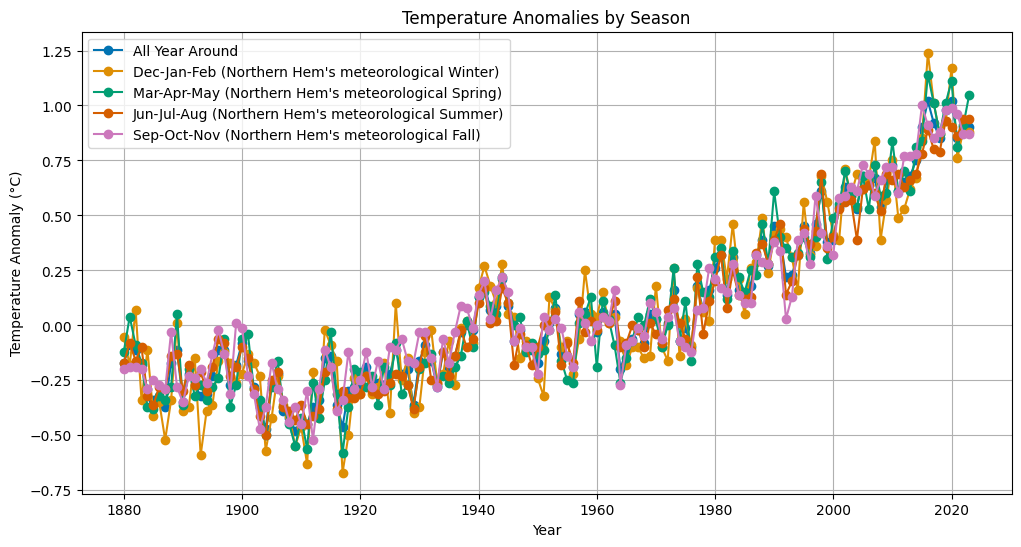

In [11]:
# Mapping of columns to season names for the legend
season_info = {
    'J-D': 'All Year Around',
    'DJF': 'Dec-Jan-Feb (Northern Hem\'s meteorological Winter)',
    'MAM': 'Mar-Apr-May (Northern Hem\'s meteorological Spring)',
    'JJA': 'Jun-Jul-Aug (Northern Hem\'s meteorological Summer)',
    'SON': 'Sep-Oct-Nov (Northern Hem\'s meteorological Fall)'
}

# Set the seaborn color palette so that each season gets a distinct color
sns.set_palette("colorblind")

# Plot each season on the same graph
plt.figure(figsize=(12,6))
for col, title in season_info.items():
    plt.plot(df['Year'], df[col], marker='o', label=title)

plt.title('Temperature Anomalies by Season')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.grid(True)
plt.legend()
plt.show()

## Finding & Visualizing Outliers

### IQR Method

In [12]:
Q1 = df['J-D'].quantile(0.25)
Q3 = df['J-D'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = df[(df['J-D'] < lower_bound) | (df['J-D'] > upper_bound)]
print("Outliers:\n", outliers)

Outliers:
      Year   Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov  \
136  2016  1.17  1.37  1.36  1.10  0.95  0.80  0.84  1.02  0.91  0.89  0.92   
140  2020  1.18  1.25  1.17  1.13  1.02  0.92  0.90  0.88  0.99  0.89  1.11   

      Dec   J-D   D-N   DJF   MAM   JJA   SON  
136  0.87  1.02  1.04  1.24  1.14  0.89  0.91  
140  0.81  1.02  1.04  1.17  1.11  0.90  0.99  


### Z-Score Method

In [13]:
from scipy.stats import zscore

z_score = zscore(df['SON'])
print(z_score)
threshold = 3 # 3 SDs away from the mean

ol = df[abs(z_score) > threshold]
print(ol)

0     -0.759493
1     -0.732213
2     -0.732213
3     -0.759493
4     -1.005017
         ...   
139    2.459592
140    2.486872
141    2.405031
142    2.159508
143    2.159508
Name: SON, Length: 144, dtype: float64
Empty DataFrame
Columns: [Year, Jan, Feb, Mar, Apr, May, Jun, Jul, Aug, Sep, Oct, Nov, Dec, J-D, D-N, DJF, MAM, JJA, SON]
Index: []


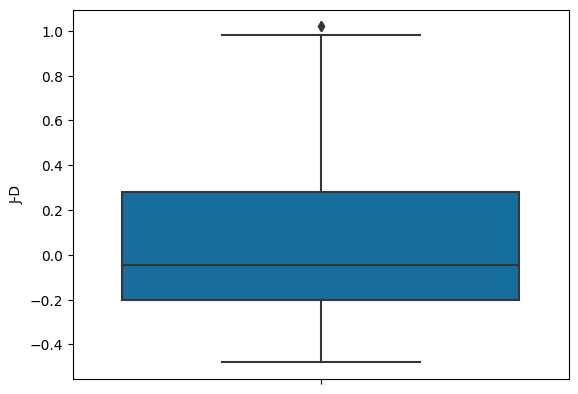

In [14]:
sns.boxplot(y=df['J-D'], color=sns.color_palette()[0])

plt.show()

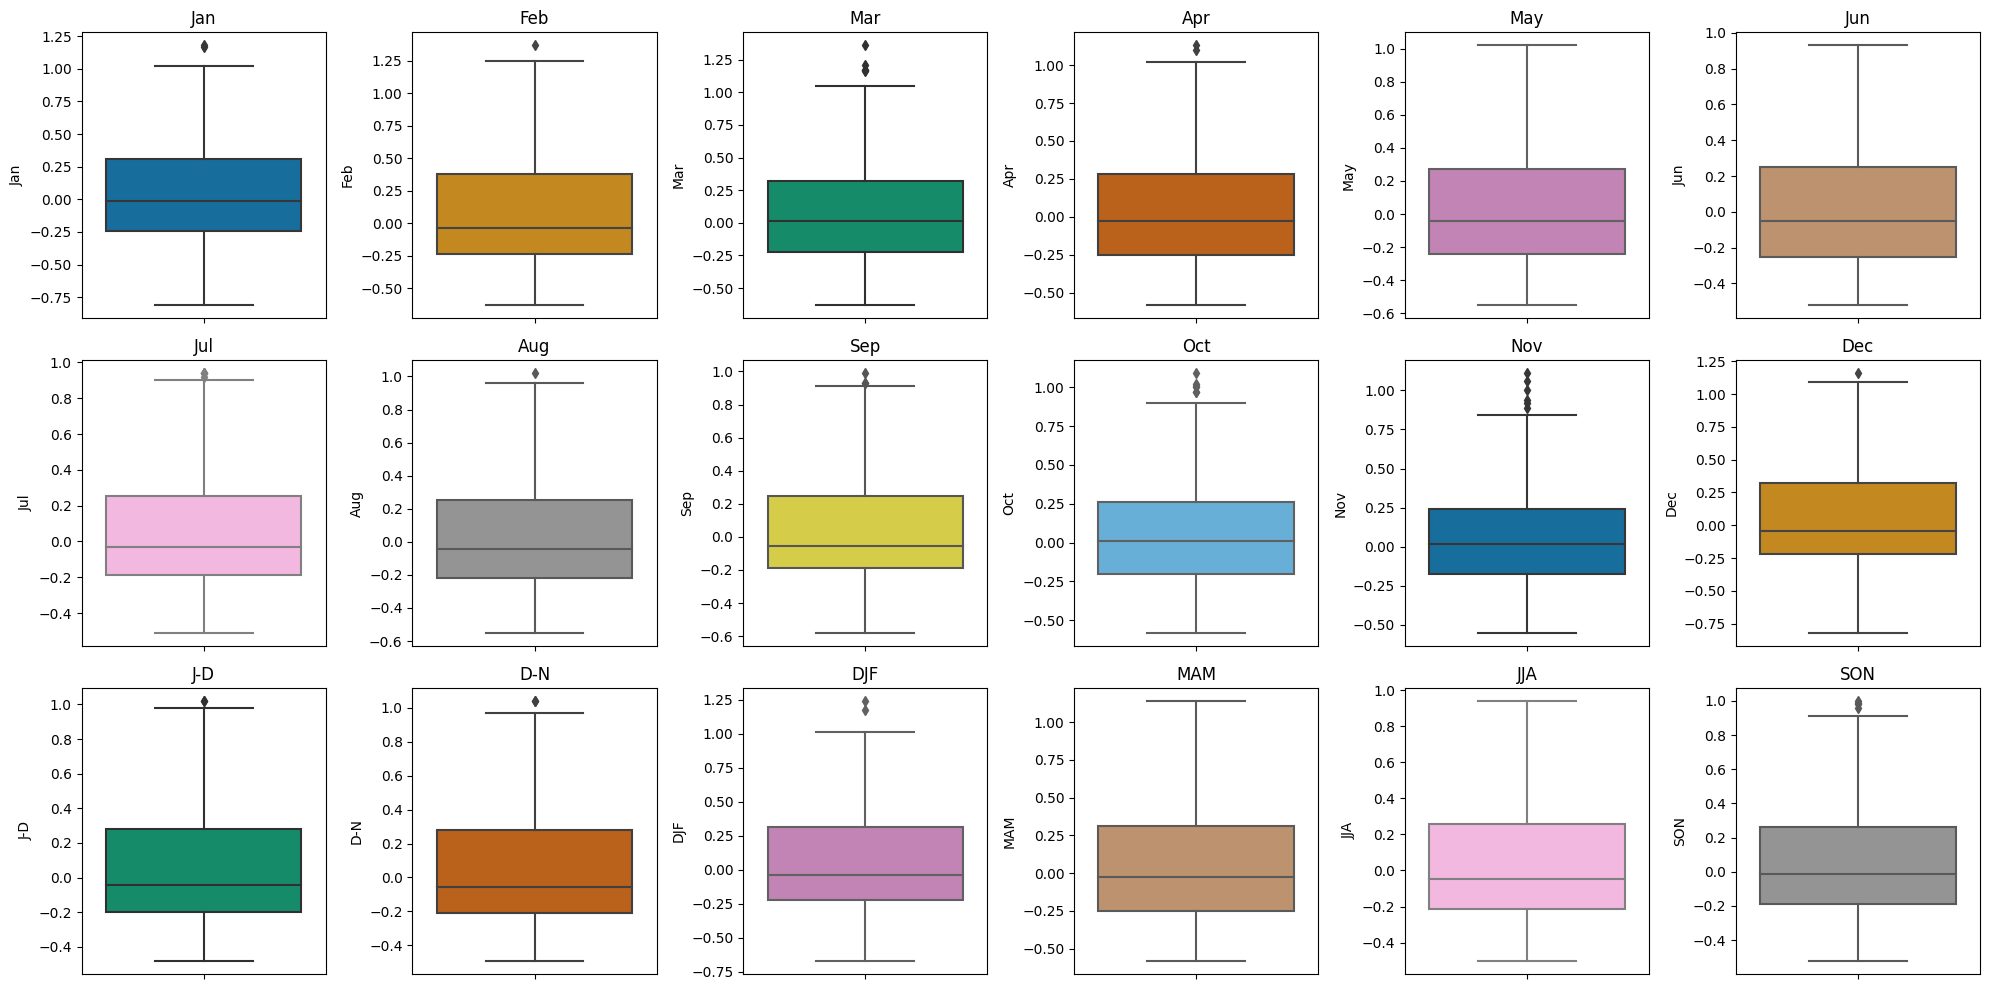

In [15]:
# Set the color palette to 'colorblind'
palette = sns.color_palette("colorblind")

plt.figure(figsize=(20,10))

# Loop through each column (excluding 'Year')
for i, column in enumerate(df.columns.drop('Year')):
    # Create a subplot for each column
    plt.subplot(3, 6, i+1)
    # Use modulo to cycle through the colorblind-friendly palette
    color = palette[i % len(palette)]
    sns.boxplot(y=df[column], color=color)
    plt.title(column)
    plt.tight_layout()

plt.show()


## Correlation Heatmap

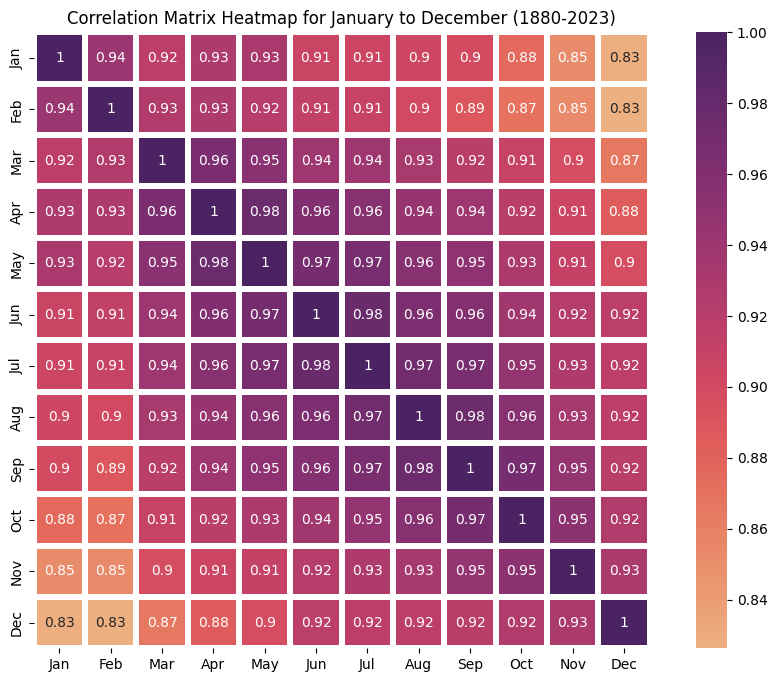

In [16]:
months_columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_months = df[months_columns]

corr_matrix = df_months.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, 
            annot = True, 
            cmap='flare', 
            linewidth=3, 
            square=True)
plt.title('Correlation Matrix Heatmap for January to December (1880-2023)')
plt.show()

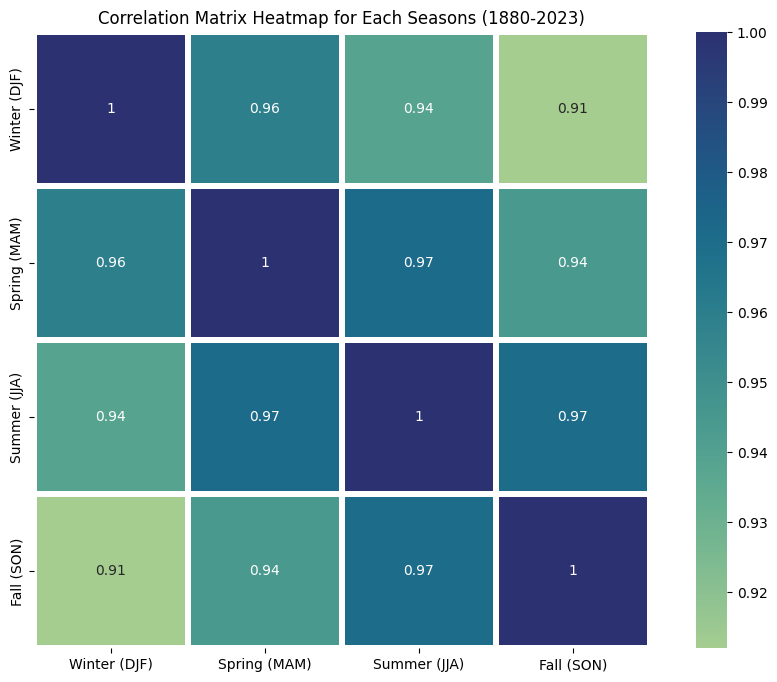

In [17]:
season_columns = ['DJF', 'MAM', 'JJA', 'SON'] # winter, spring, summer, fall
df_seasons = df[season_columns]

corr_matrix_seasons = df_seasons.corr() 
season_labels = ['Winter (DJF)', 'Spring (MAM)', 'Summer (JJA)', 'Fall (SON)']

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix_seasons, 
            annot = True, 
            cmap='crest', 
            linewidth=3, 
            xticklabels=season_labels,
            yticklabels=season_labels,
            square=True)
plt.title('Correlation Matrix Heatmap for Each Seasons (1880-2023)')
plt.show()

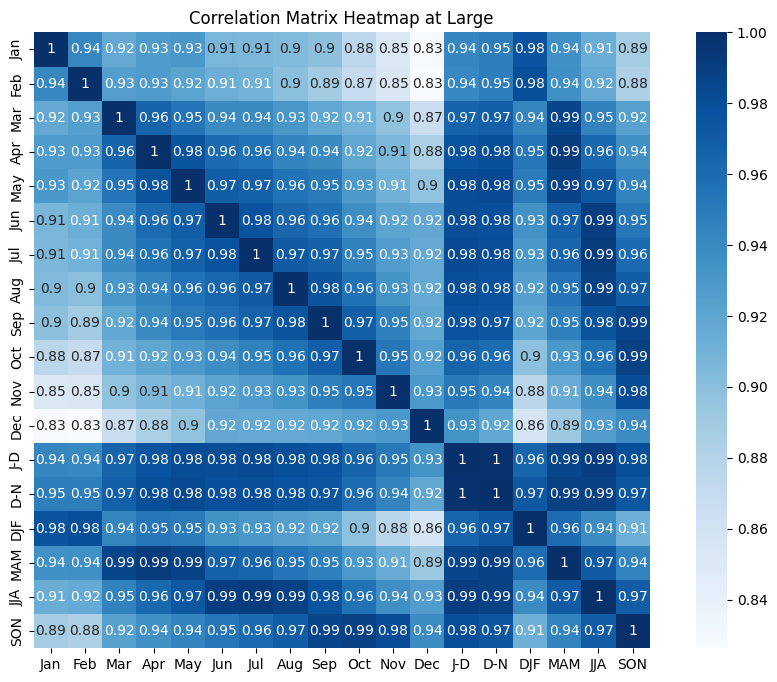

In [18]:
new_df = df.drop(columns=['Year'])
corr_matrix2 = new_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix2, 
            annot = True, 
            cmap='Blues', 
            square=True)
plt.title('Correlation Matrix Heatmap at Large')
plt.show()

### Observation from Heatmaps

1. High Correlation Among Months: There is a high degree of correlation amonth individual motnhs, but this is expected in time series data especially for climatic or environmental data, where adjacent months often have similar conditions or patterns.

2. Seasonal Correlations: The seasonal indicators (DJF, MAM, JJA, SON) also show high correlation with the individual months that comprise each season. This is also expected, as these are aggregate measure of the months they represent. 

3. Multicollinearity Consideration: In the context of linear models, multicollinearity can be problematic as it inflates the variance of the coefficient estimates and makes the model sensitive to changes in model specification. High correlations among variables indicates multicollinearity. If I will use there variables in a predictive model, I will need to address this issue. (Dimensional Reduction, Variable Selection, Regularization)

***Correlation does NOT imply causation!***

# Trend Analysis

## Rate of Change

From visual inspection of time series plots, it shows a strong trend of increase in global surface temperature. In this section, I will run the trend analysis using various statistical methods to analyze further into the phenomenon. 


Trend Analysis for J-D:
Slope: 0.007891266779197815
Intercept: -15.333765452937868


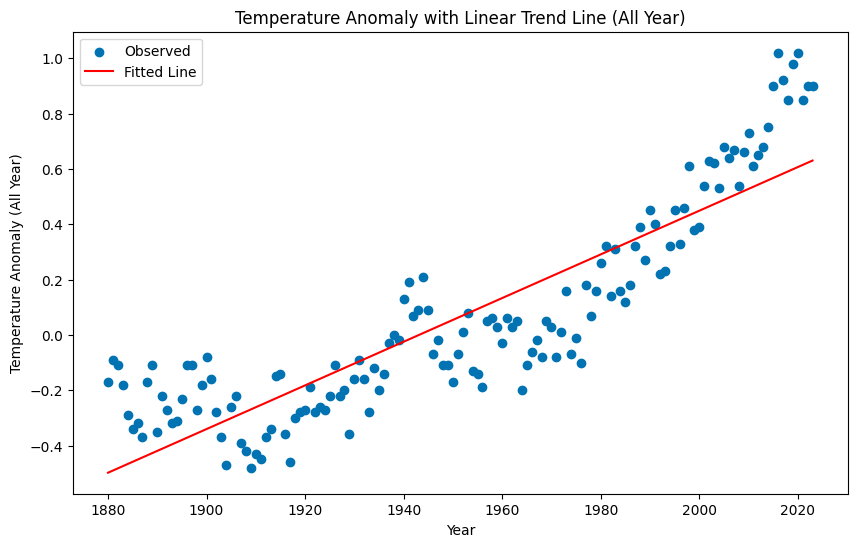


Trend Analysis for DJF:
Slope: 0.008169911984567157
Intercept: -15.880840182327251


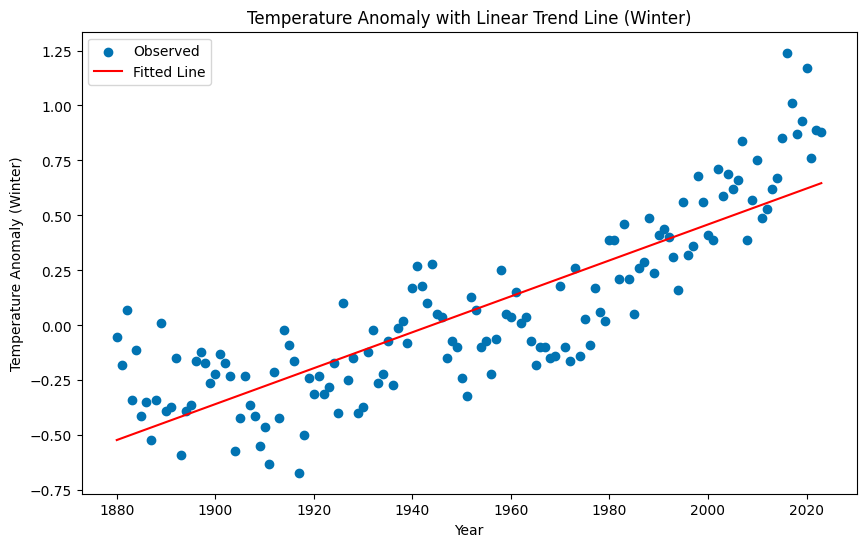


Trend Analysis for MAM:
Slope: 0.008217888433405677
Intercept: -15.968667611124511


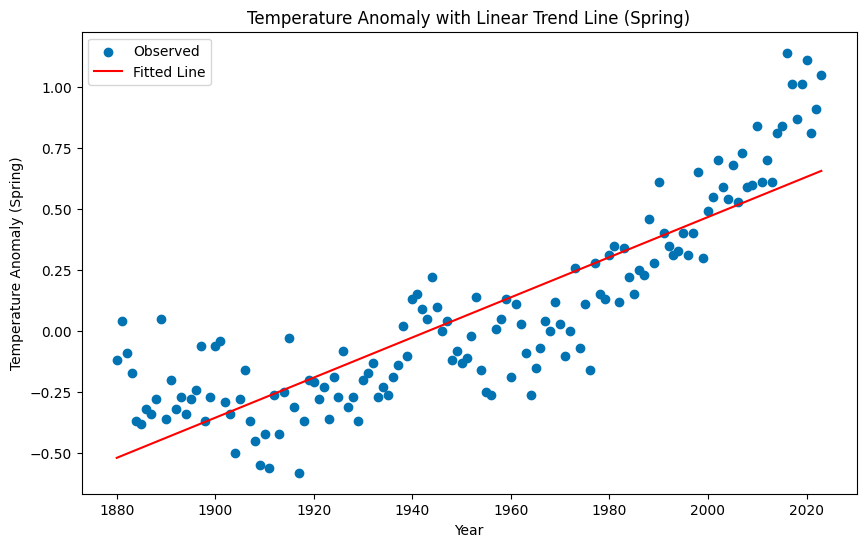


Trend Analysis for JJA:
Slope: 0.007568041154248054
Intercept: -14.715143423626188


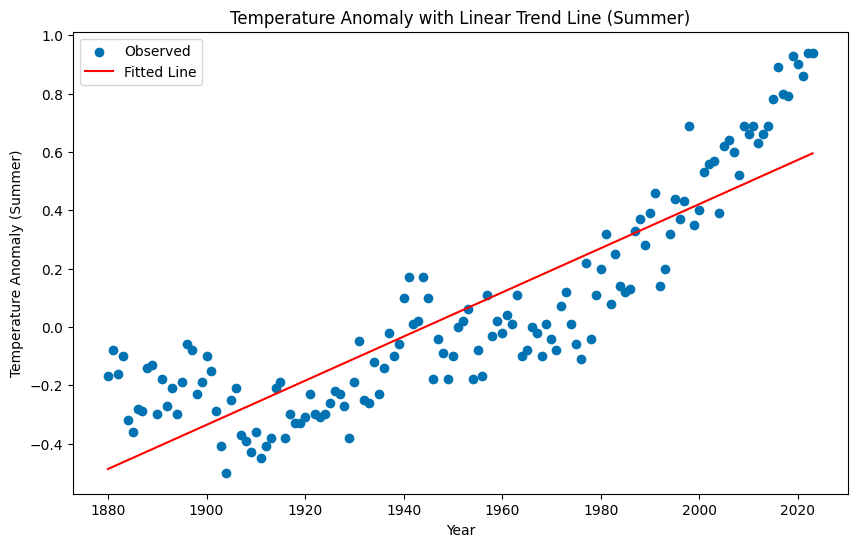


Trend Analysis for SON:
Slope: 0.007563278675347641
Intercept: -14.681335557163145


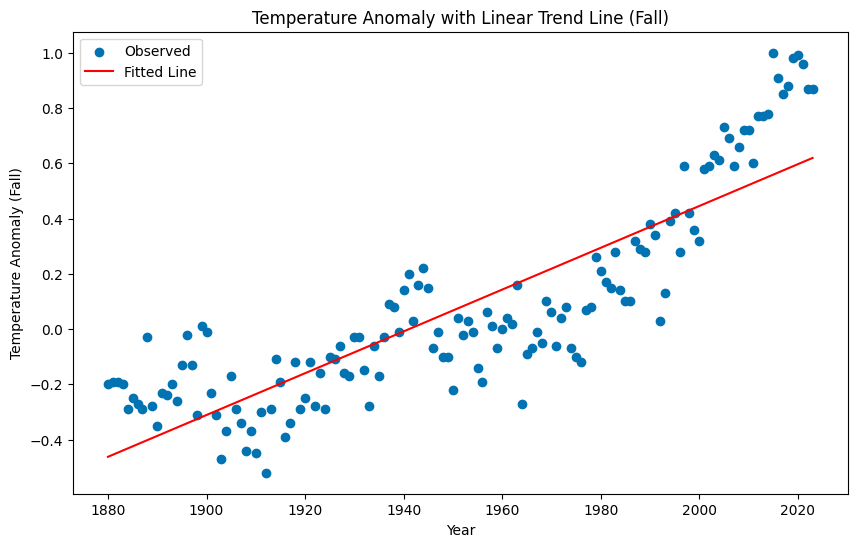

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Mapping of columns to season names
season_names = {
    'J-D': 'All Year',
    'DJF': 'Winter',
    'MAM': 'Spring',
    'JJA': 'Summer',
    'SON': 'Fall'
}

X = df['Year'].values.reshape(-1, 1)

for col, season in season_names.items():
    y = df[col]

    model = LinearRegression().fit(X, y)
    print(f"\nTrend Analysis for {col}:")
    print(f"Slope: {model.coef_[0]}")
    print(f"Intercept: {model.intercept_}")

    y_pred = model.predict(X)

    plt.figure(figsize=(10, 6))
    plt.scatter(df['Year'], y, label='Observed')
    plt.plot(df['Year'], y_pred, color='red', label='Fitted Line')
    plt.xlabel('Year')
    plt.ylabel(f'Temperature Anomaly ({season})')
    plt.title(f'Temperature Anomaly with Linear Trend Line ({season})')
    plt.legend()
    plt.show()


## Moving Average Method

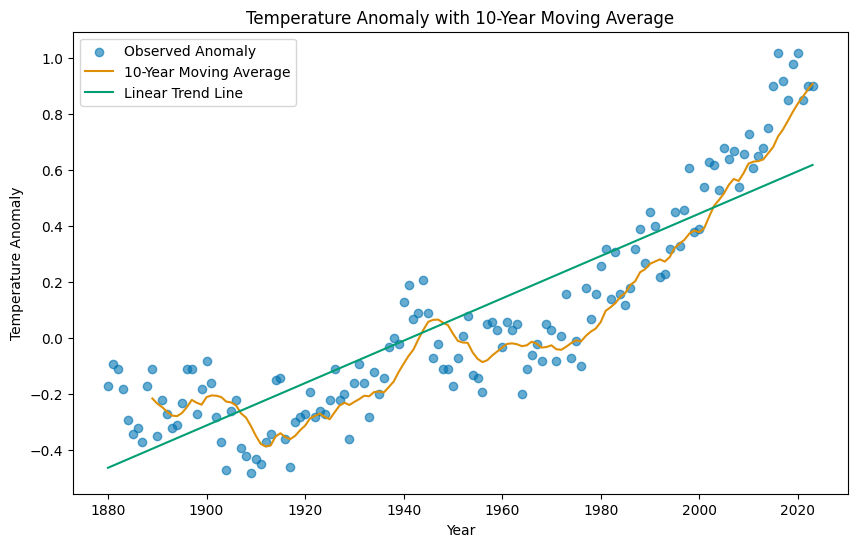

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

palette = sns.color_palette("colorblind", 3)
window_size = 10 # try different size of window
df['Moving_Avg'] = df['J-D'].rolling(window=window_size).mean()

plt.figure(figsize=(10,6))
plt.scatter(df['Year'], df['J-D'], alpha=0.6, label='Observed Anomaly')
plt.plot(df['Year'], df['Moving_Avg'], color=palette[1], label=f'{window_size}-Year Moving Average')
plt.plot(df['Year'], y_pred, color=palette[2], label='Linear Trend Line')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly')
plt.title(f'Temperature Anomaly with {window_size}-Year Moving Average')
plt.legend()
plt.show()


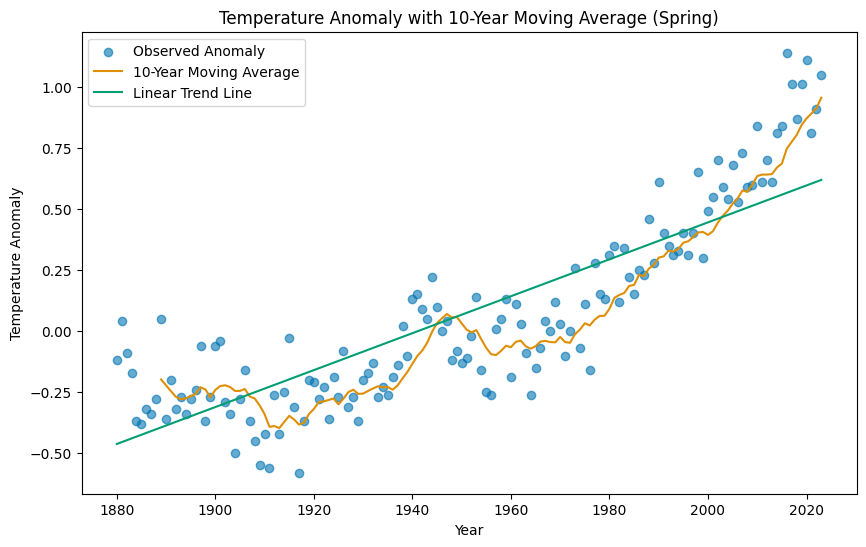

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

palette = sns.color_palette("colorblind", 3)
window_size = 10 # try different size of window
df['Moving_Avg_S'] = df['MAM'].rolling(window=window_size).mean()

plt.figure(figsize=(10,6))
plt.scatter(df['Year'], df['MAM'], alpha=0.6, label='Observed Anomaly')
plt.plot(df['Year'], df['Moving_Avg_S'], color=palette[1], label=f'{window_size}-Year Moving Average')
plt.plot(df['Year'], y_pred, color=palette[2], label='Linear Trend Line')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly')
plt.title(f'Temperature Anomaly with {window_size}-Year Moving Average (Spring)')
plt.legend()
plt.show()

# Statistical Analysis

## ANOVA

**One-Way ANOVA is suitable when:**

1. Group Comparison: there are multiple groups to compare
2. One Factor: groups that can be categorized in one factor
3. Independence of observations: under assumptions that the observations in each group are independent of each other
4. Normality: under assumptions that residuals are normally distributed and variances of the groups are equal.

Normality Test prior to ANOVA

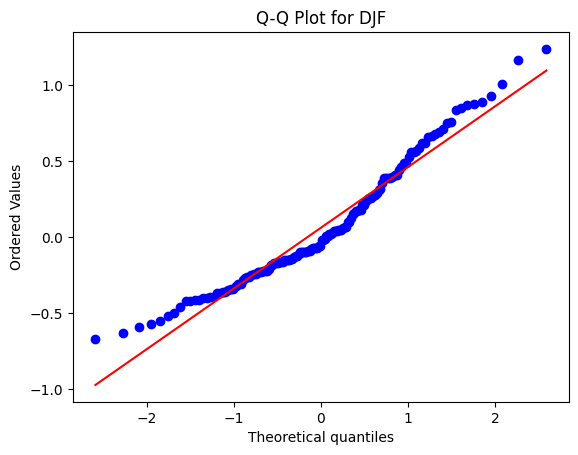

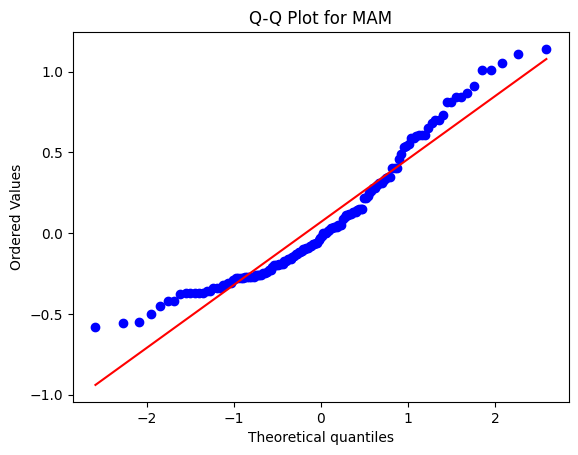

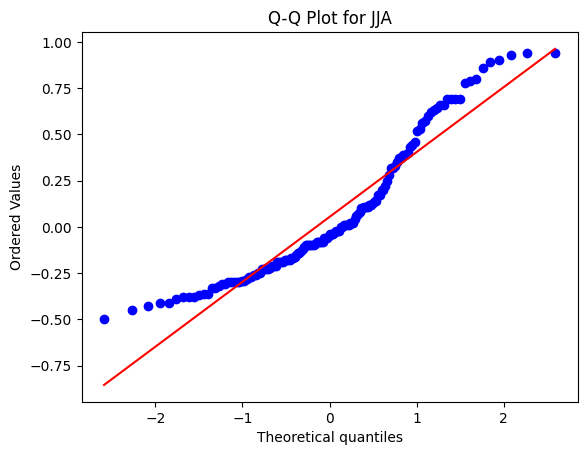

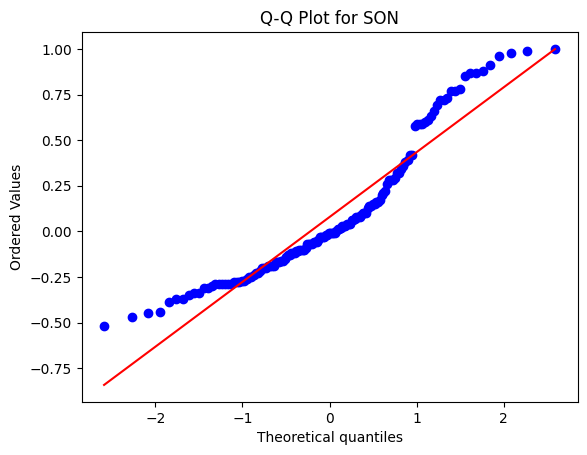

In [22]:
## Q-Q Plot

import scipy.stats as stats
import matplotlib.pyplot as plt

seasons = ['DJF', 'MAM', 'JJA', 'SON']

for season in seasons:
    plt.figure()
    stats.probplot(df[season], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot for {season}')
    plt.show()


In [23]:
from scipy.stats import shapiro

for season in seasons:
    stat, p = shapiro(df[season])
    print(f'{season}: Statistics={stat}, p={p}')
    if p > 0.05:
        print('Sample looks Gaussian (fail to reject H0)')
    else:
        print('Sample does not look Gaussian (reject H0)')


DJF: Statistics=0.9555511474609375, p=0.00013722883886657655
Sample does not look Gaussian (reject H0)
MAM: Statistics=0.9312835931777954, p=1.8837203015209525e-06
Sample does not look Gaussian (reject H0)
JJA: Statistics=0.912170946598053, p=1.1155611190361014e-07
Sample does not look Gaussian (reject H0)
SON: Statistics=0.9089100956916809, p=7.146584124484434e-08
Sample does not look Gaussian (reject H0)


Given visual inspection of Q-Q plot and the Shapiro-Wilk test, the result has indicated that the seasonal data groups do not follow a normal distribution. Considering a small sample size, the use of one-way ANOVA might not be appropriate although ANOVA is know to be robust to violations of the normality assumptions, this is true with larger sample sizes. 

Since ANOVA might not be the suitable method, I will opt for the Kruskal-Willis H-Test, the non-parametric alternative to ANOVA which does not assume normal distribution of the residual. 

## The Kruskal-Willis Test

**Null Hypothesis (H0):**
There are no significant differences in the mean temp anomalies among the four seasons.

**Alternative Hypothesis (H1):**
There is at least one season where the mean temp anomaly is significantly different from the others, which suggesting that not all seasonal means are equal.

In [24]:
from scipy import stats
import pandas as pd

season_data = df[['DJF', 'MAM', 'JJA', 'SON']].stack()

# Creating a new data structure
season_df = pd.DataFrame({'Season': season_data.index.get_level_values(1), 'Anomaly': season_data.values})
print(season_df)

# Kruskal-Wallis test
h_stat, p_value = stats.kruskal(season_df[season_df['Season'] == 'DJF']['Anomaly'],
                                season_df[season_df['Season'] == 'MAM']['Anomaly'],
                                season_df[season_df['Season'] == 'JJA']['Anomaly'],
                                season_df[season_df['Season'] == 'SON']['Anomaly'])
print("Kruskal-Wallis Test Results: H-Stat =", h_stat, ", P-value =", p_value)


    Season  Anomaly
0      DJF   -0.055
1      MAM   -0.120
2      JJA   -0.170
3      SON   -0.200
4      DJF   -0.180
..     ...      ...
571    SON    0.870
572    DJF    0.880
573    MAM    1.050
574    JJA    0.940
575    SON    0.870

[576 rows x 2 columns]
Kruskal-Wallis Test Results: H-Stat = 0.5677597652070906 , P-value = 0.9037717117061478


H-Stat: a measure of the overall deviation from the null hypothesis. The observed H-Stat value is relatively low, suggesting that the deviation from the null hypothesis is not substantial. 

P-value: a measure of the probability of observing a test statistic as extreme as or more extreme than the one observed under the null hypothesis. The observed p-value is much higher than a threshold (0.05), indicating that the observed data is quite likely under the null hypothesis. 

**Interpretation**

The observed p-value is much higher than the commonly used threshold of 0.05. Therefore I do not have sufficient evience to reject the Null Hypothesis, meaning that there is no statistically significant difference in the mean temp anomalies across the different seasons. The variations in mean temp anomalies among the seasons could be due to random chance rather than a real difference in their underlying means. 

## Time Series Decomposition

Time Series Decomposition involves seperating a time series into several components (Trend, Seasonal, and Residual).

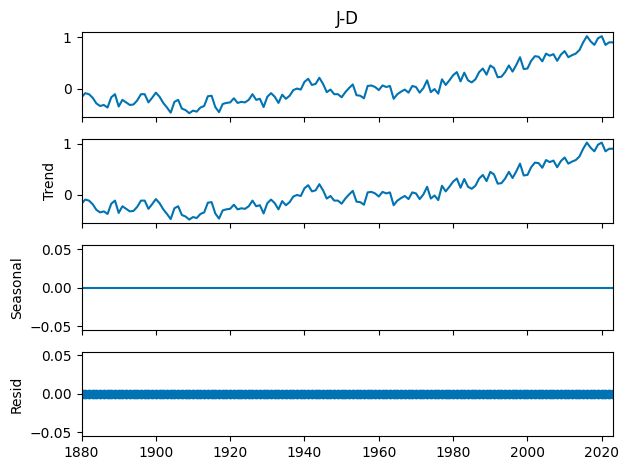

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Convert year to datetime format to prepare for seasonal_decompose
df['Year'] = pd.to_datetime(df['Year'], format='%Y')
df.set_index('Year', inplace=True)

result = seasonal_decompose(df['J-D'], model='additive')

result.plot()
plt.show()

**Trend Component:** The increasing trend is visible even with its zigzag pattern, indicating that there is a general upward movement in temp anomalies over time. This is a clear sign of a warming trend, which is consistent with global warming observation. 

**Seasonal Component:** The seasonal component staying around 0 with a horizontal line suggests that there is not a strong seasonal cycle in the data. 

**Residual Component:** The residuals hovoring around 0.00 with a thick line indicates the random or unexplained variability in the data after the Trend and Seasonal Components have been accounted for. While the model has captured the general pattern, there's still some volatility or noise in the data that isn't explained by the model. This could be caused by many potential factors, including unexpected variability in climate data. 

## Mann-Kendall Trend Test

Mann-Kendall Trend Test is a non-parametric test used to identify and confirm trends in time series data. It can help confirm whether the trend is statistically significant, without any assumptions of specific distribution of the data. 

**Null Hypothesis (H0):**
There is no trend in the temperature anomalies over time for the given season.

**Alternative Hypothesis (H1):**
There is a trend in the temp anomalies over time for the given season. 

In [26]:
!pip install pymannkendall

### M-K Trend Test for All-Year

In [27]:
import pymannkendall as mk

result = mk.original_test(df['J-D'])

print(f"Trend: {result.trend}")
print(f"P-value: {result.p}")
print(f"Z-value: {result.z}")
print(f"Slope (Sen's slope): {result.slope}")

Trend: increasing
P-value: 0.0
Z-value: 12.79844423780263
Slope (Sen's slope): 0.007869611414693382


**Trend** is increasing. 

The observed **p-value** indicates that the observed increasing trend is statistically significant. The probability of observing such a trend in the temp anomalies by random chance is extremely small. 

The observed **z-value**, given its magnitude far from 0, indicates a strong trend. In this case, a positive z-value supports the finding of an inceasing trend. 

**Sen's Slope** represents the magnitude of change in the temperature anomalies per year. The observed value indicates that the temp anomalies are increasing by **0.0079 degrees** C per year. 

Interpretation: The M-K test results strongly suggest that there is a statisticaly significant increasing trend in the temp anomalies over the years, evidenced by a very low p-value and a high Z-value. 

### M-K Trend Test for Seasonal

Different seasons might be differently affected by climate change. 

In [28]:
seasons = ['DJF','MAM','JJA','SON']

mk_results = {}
for season in seasons:
    result = mk.original_test(df[season])
    #print(result)
    mk_results[season] = {
        'Trend': result.trend,
        'P-value': result.p,
        'Z-value': result.z,
        'Slope': result.slope
    }
    print(mk_results[season])

for season, results in mk_results.items():
    print(f"Season: {season}, Results: {results}")

{'Trend': 'increasing', 'P-value': 0.0, 'Z-value': 11.663932661392066, 'Slope': 0.008177447552447552}
{'Trend': 'increasing', 'P-value': 0.0, 'Z-value': 12.348529934317783, 'Slope': 0.00823529411764706}
{'Trend': 'increasing', 'P-value': 0.0, 'Z-value': 12.563346103483624, 'Slope': 0.007600000000000001}
{'Trend': 'increasing', 'P-value': 0.0, 'Z-value': 12.423191546123872, 'Slope': 0.007318330399798843}
Season: DJF, Results: {'Trend': 'increasing', 'P-value': 0.0, 'Z-value': 11.663932661392066, 'Slope': 0.008177447552447552}
Season: MAM, Results: {'Trend': 'increasing', 'P-value': 0.0, 'Z-value': 12.348529934317783, 'Slope': 0.00823529411764706}
Season: JJA, Results: {'Trend': 'increasing', 'P-value': 0.0, 'Z-value': 12.563346103483624, 'Slope': 0.007600000000000001}
Season: SON, Results: {'Trend': 'increasing', 'P-value': 0.0, 'Z-value': 12.423191546123872, 'Slope': 0.007318330399798843}


**Interpretation:**

All seasons show a statistically significant increasing trend in temp anomalies, comfirming that global warming is affecting all parts of the year with slightly different rate. The slope values across the seasons indicate the rate of increase is somewhat uniform. The consistent significance across all seasons indicate the robustness of the Warming Trend. 

## Change Point Analysis

To identify points in time where the statistical properties of a time series change

In [29]:
!pip install ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.3 MB/s eta 0:00:00


### Change Point Detection for All-Year

In [30]:
# Reset the dataset
df = pd.read_csv('/kaggle/input/global-surface-temperatures/global_temps.csv')
for column in df.columns:
    if df[column].isnull().any():
        df[column] = df[column].interpolate(method='linear')
if df.iloc[0].isnull().any():
    mean_val = df.iloc[1:3].mean()
    df.iloc[0] = df.iloc[0].fillna(mean_val)
# Check dataset
df.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.19,-0.25,-0.09,-0.17,-0.10,-0.21,-0.18,-0.11,-0.15,-0.24,-0.22,-0.18,-0.17,-0.095,-0.055,-0.12,-0.17,-0.20
1,1881,-0.20,-0.15,0.03,0.05,0.05,-0.19,0.00,-0.04,-0.16,-0.22,-0.19,-0.08,-0.09,-0.100,-0.180,0.04,-0.08,-0.19
2,1882,0.16,0.13,0.04,-0.16,-0.14,-0.22,-0.17,-0.08,-0.15,-0.24,-0.17,-0.36,-0.11,-0.090,0.070,-0.09,-0.16,-0.19
3,1883,-0.30,-0.37,-0.13,-0.19,-0.18,-0.08,-0.08,-0.14,-0.23,-0.12,-0.24,-0.11,-0.18,-0.200,-0.340,-0.17,-0.10,-0.20
4,1884,-0.13,-0.09,-0.37,-0.40,-0.34,-0.35,-0.31,-0.28,-0.28,-0.25,-0.34,-0.31,-0.29,-0.270,-0.110,-0.37,-0.32,-0.29


[-0.17 -0.09 -0.11 -0.18 -0.29 -0.34 -0.32 -0.37 -0.17 -0.11 -0.35 -0.22
 -0.27 -0.32 -0.31 -0.23 -0.11 -0.11 -0.27 -0.18 -0.08 -0.16 -0.28 -0.37
 -0.47 -0.26 -0.22 -0.39 -0.42 -0.48 -0.43 -0.45 -0.37 -0.34 -0.15 -0.14
 -0.36 -0.46 -0.3  -0.28 -0.27 -0.19 -0.28 -0.26 -0.27 -0.22 -0.11 -0.22
 -0.2  -0.36 -0.16 -0.09 -0.16 -0.28 -0.12 -0.2  -0.14 -0.03  0.   -0.02
  0.13  0.19  0.07  0.09  0.21  0.09 -0.07 -0.02 -0.11 -0.11 -0.17 -0.07
  0.01  0.08 -0.13 -0.14 -0.19  0.05  0.06  0.03 -0.03  0.06  0.03  0.05
 -0.2  -0.11 -0.06 -0.02 -0.08  0.05  0.03 -0.08  0.01  0.16 -0.07 -0.01
 -0.1   0.18  0.07  0.16  0.26  0.32  0.14  0.31  0.16  0.12  0.18  0.32
  0.39  0.27  0.45  0.4   0.22  0.23  0.32  0.45  0.33  0.46  0.61  0.38
  0.39  0.54  0.63  0.62  0.53  0.68  0.64  0.67  0.54  0.66  0.73  0.61
  0.65  0.68  0.75  0.9   1.02  0.92  0.85  0.98  1.02  0.85  0.9   0.9 ]
[50, 60, 65, 100, 120, 144]
Change Point 1: Year 1930, Position 50
Change Point 2: Year 1940, Position 60
Change Point 3: Y

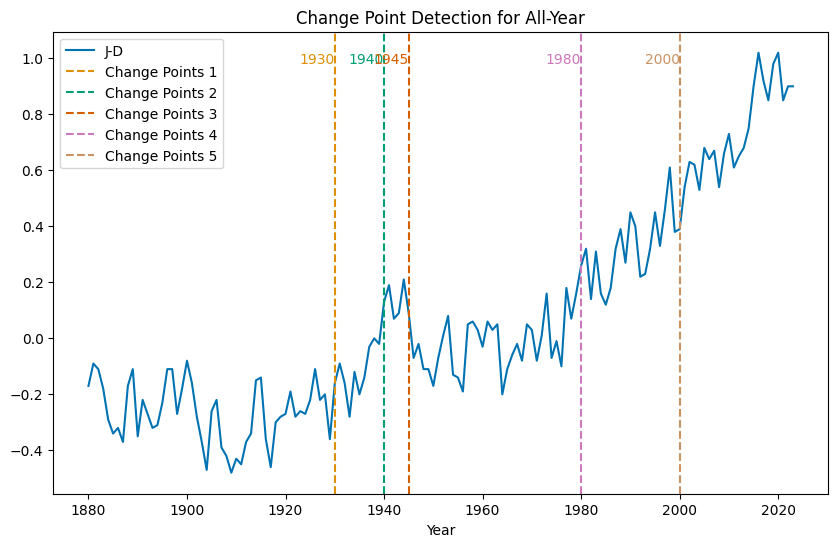

In [31]:
import ruptures as rpt

points = df["J-D"].values
print(points)

# Search, binary segmentation
algo = rpt.Binseg(model="rank").fit(points)
result = algo.predict(n_bkps=5) # number of breakpoints to detect
print(result)

# Plotting
plt.figure(figsize=(10,6))
plt.plot(df['Year'], points, label='J-D')
palette = sns.color_palette("colorblind")

# Addinv vertical lines for change points
for i, cp in enumerate(result[:-1]):
    year = df['Year'].iloc[cp]
    color = palette[i+1]
    plt.axvline(x=year, color=color, linestyle='--', label=f'Change Points {i+1}')
    plt.text(year, max(points), f'{year}', color=color, verticalalignment='top', horizontalalignment='right')
    print(f"Change Point {i+1}: Year {year}, Position {cp}")

plt.xlabel('Year')
plt.title('Change Point Detection for All-Year')
plt.legend()
plt.show()

The model to choose from:

l1, l2, rbf, linear, normal, ar, rank, mahalanobis

**Interpretation:**

Change Point 1 - Year 1930: This point could indicate the beginning of a significant warming phase. It could be due to the early impacts of industrialization. 

Change Point 2 - Year 1940: A decade later, this point suggests another shift in the temperature trend. The period around 1940 marks the beginning of short period of cooling phase, followed by the rapid increase. It could be attributed to factors like natural climate variability. 

Change Point 3 - Year 1945: The mid-1940s are significant for historical reasons, including the end of World War II, which could have influenced atmospheric conditions through industrial activities during the War time. 

Change Point 4 - Year 1980: The early 1980s marks the beginning of the Global Warming, and the warming trend was observed towards the end of the 20th century and continuing well into the 21st century. 

Change Poing 5 - Year 2000: The critical change point came the Year 2000. The early 21st century has seen some of the warmest years on record across the world, suggesting an acceleration of climate change impacts. 

### Change Point Detection for Each Season

[-0.055 -0.18   0.07  -0.34  -0.11  -0.41  -0.35  -0.52  -0.34   0.01
 -0.39  -0.37  -0.15  -0.59  -0.39  -0.36  -0.16  -0.12  -0.17  -0.26
 -0.22  -0.13  -0.17  -0.23  -0.57  -0.42  -0.23  -0.36  -0.41  -0.55
 -0.46  -0.63  -0.21  -0.42  -0.02  -0.09  -0.16  -0.67  -0.5   -0.24
 -0.31  -0.23  -0.31  -0.28  -0.17  -0.4    0.1   -0.25  -0.15  -0.4
 -0.37  -0.12  -0.02  -0.26  -0.22  -0.07  -0.27  -0.01   0.02  -0.08
  0.17   0.27   0.18   0.1    0.28   0.05   0.04  -0.15  -0.07  -0.1
 -0.24  -0.32   0.13   0.07  -0.1   -0.07  -0.22  -0.06   0.25   0.05
  0.04   0.15   0.01   0.04  -0.07  -0.18  -0.1   -0.1   -0.15  -0.14
  0.18  -0.1   -0.16   0.26  -0.14   0.03  -0.09   0.17   0.06   0.02
  0.39   0.39   0.21   0.46   0.21   0.05   0.26   0.29   0.49   0.24
  0.41   0.44   0.4    0.31   0.16   0.56   0.32   0.36   0.68   0.56
  0.41   0.39   0.71   0.59   0.69   0.62   0.66   0.84   0.39   0.57
  0.75   0.49   0.53   0.62   0.67   0.85   1.24   1.01   0.87   0.93
  1.17   0.76   0.89  

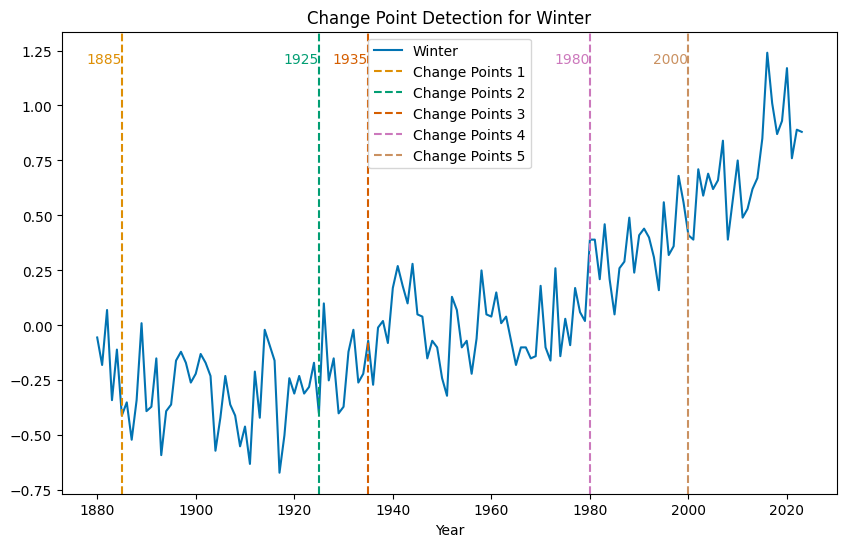

[-0.12  0.04 -0.09 -0.17 -0.37 -0.38 -0.32 -0.34 -0.28  0.05 -0.36 -0.2
 -0.32 -0.27 -0.34 -0.28 -0.24 -0.06 -0.37 -0.27 -0.06 -0.04 -0.29 -0.34
 -0.5  -0.28 -0.16 -0.37 -0.45 -0.55 -0.42 -0.56 -0.26 -0.42 -0.25 -0.03
 -0.31 -0.58 -0.37 -0.2  -0.21 -0.28 -0.23 -0.36 -0.19 -0.27 -0.08 -0.31
 -0.27 -0.37 -0.2  -0.17 -0.13 -0.27 -0.23 -0.26 -0.19 -0.14  0.02 -0.1
  0.13  0.15  0.09  0.05  0.22  0.1   0.    0.04 -0.12 -0.08 -0.13 -0.11
 -0.02  0.14 -0.16 -0.25 -0.26  0.01  0.05  0.13 -0.19  0.11  0.03 -0.09
 -0.26 -0.15 -0.07  0.04  0.    0.12  0.03 -0.1   0.    0.26 -0.07  0.11
 -0.16  0.28  0.15  0.13  0.31  0.35  0.12  0.34  0.22  0.15  0.25  0.23
  0.46  0.28  0.61  0.4   0.35  0.31  0.33  0.4   0.31  0.4   0.65  0.3
  0.49  0.55  0.7   0.59  0.54  0.68  0.53  0.73  0.59  0.6   0.84  0.61
  0.7   0.61  0.81  0.84  1.14  1.01  0.87  1.01  1.11  0.81  0.91  1.05]
[5, 55, 95, 100, 120, 144]
Change Point 1: Year 1885, Position 5, Y-Position 1.14
Change Point 2: Year 1935, Position 55, Y-Po

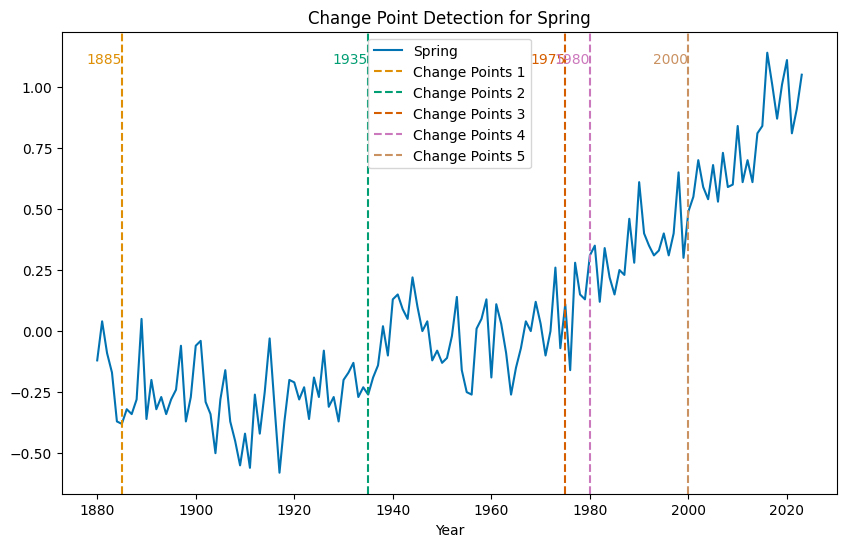

[-0.17 -0.08 -0.16 -0.1  -0.32 -0.36 -0.28 -0.29 -0.14 -0.13 -0.3  -0.18
 -0.27 -0.21 -0.3  -0.19 -0.06 -0.08 -0.23 -0.19 -0.1  -0.15 -0.29 -0.41
 -0.5  -0.25 -0.21 -0.37 -0.39 -0.43 -0.36 -0.45 -0.41 -0.38 -0.21 -0.19
 -0.38 -0.3  -0.33 -0.33 -0.31 -0.23 -0.3  -0.31 -0.3  -0.26 -0.22 -0.23
 -0.27 -0.38 -0.19 -0.05 -0.25 -0.26 -0.12 -0.23 -0.14 -0.02 -0.1  -0.06
  0.1   0.17  0.01  0.02  0.17  0.1  -0.18 -0.04 -0.09 -0.18 -0.1   0.
  0.02  0.06 -0.18 -0.08 -0.17  0.11 -0.03  0.02 -0.02  0.04  0.01  0.11
 -0.1  -0.08  0.   -0.02 -0.1   0.01 -0.04 -0.08  0.07  0.12  0.01 -0.06
 -0.11  0.22 -0.04  0.11  0.2   0.32  0.08  0.25  0.14  0.12  0.13  0.33
  0.37  0.28  0.39  0.46  0.14  0.2   0.32  0.44  0.37  0.43  0.69  0.35
  0.4   0.53  0.56  0.57  0.39  0.62  0.64  0.6   0.52  0.69  0.66  0.69
  0.63  0.66  0.69  0.78  0.89  0.8   0.79  0.93  0.9   0.86  0.94  0.94]
[20, 50, 60, 100, 125, 144]
Change Point 1: Year 1900, Position 20, Y-Position 0.94
Change Point 2: Year 1930, Position 50, Y

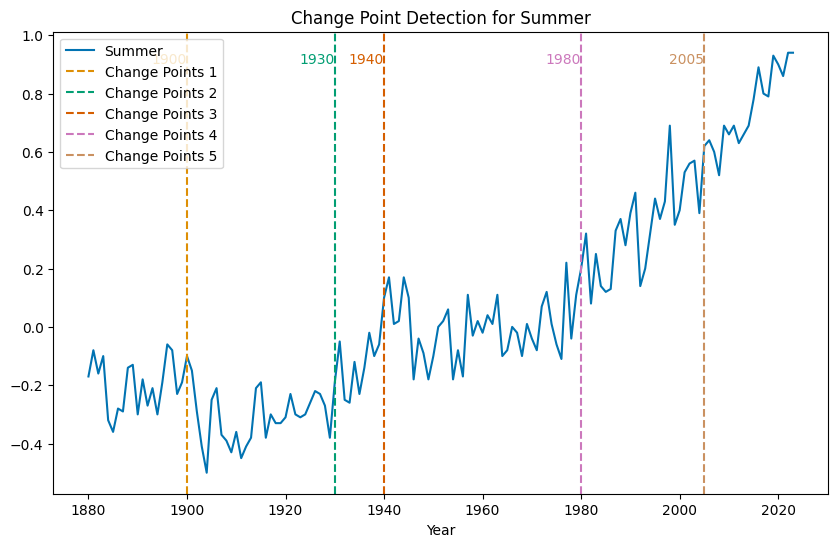

[-0.2  -0.19 -0.19 -0.2  -0.29 -0.25 -0.27 -0.29 -0.03 -0.28 -0.35 -0.23
 -0.24 -0.2  -0.26 -0.13 -0.02 -0.13 -0.31  0.01 -0.01 -0.23 -0.31 -0.47
 -0.37 -0.17 -0.29 -0.34 -0.44 -0.37 -0.45 -0.3  -0.52 -0.29 -0.11 -0.19
 -0.39 -0.34 -0.12 -0.29 -0.25 -0.12 -0.28 -0.16 -0.29 -0.1  -0.11 -0.06
 -0.16 -0.17 -0.03 -0.03 -0.15 -0.28 -0.06 -0.17 -0.03  0.09  0.08 -0.01
  0.14  0.2   0.03  0.16  0.22  0.15 -0.07 -0.01 -0.1  -0.1  -0.22  0.04
 -0.02  0.03 -0.01 -0.14 -0.19  0.06  0.01 -0.07  0.    0.04  0.02  0.16
 -0.27 -0.09 -0.07 -0.01 -0.05  0.1   0.06 -0.06  0.04  0.08 -0.07 -0.1
 -0.12  0.07  0.08  0.26  0.21  0.17  0.15  0.28  0.14  0.1   0.1   0.32
  0.29  0.28  0.38  0.34  0.03  0.13  0.39  0.42  0.28  0.59  0.42  0.36
  0.32  0.58  0.59  0.63  0.61  0.73  0.69  0.59  0.66  0.72  0.72  0.6
  0.77  0.77  0.78  1.    0.91  0.85  0.88  0.98  0.99  0.96  0.87  0.87]
[45, 55, 65, 100, 120, 144]
Change Point 1: Year 1925, Position 45, Y-Position 1.0
Change Point 2: Year 1935, Position 55, Y-

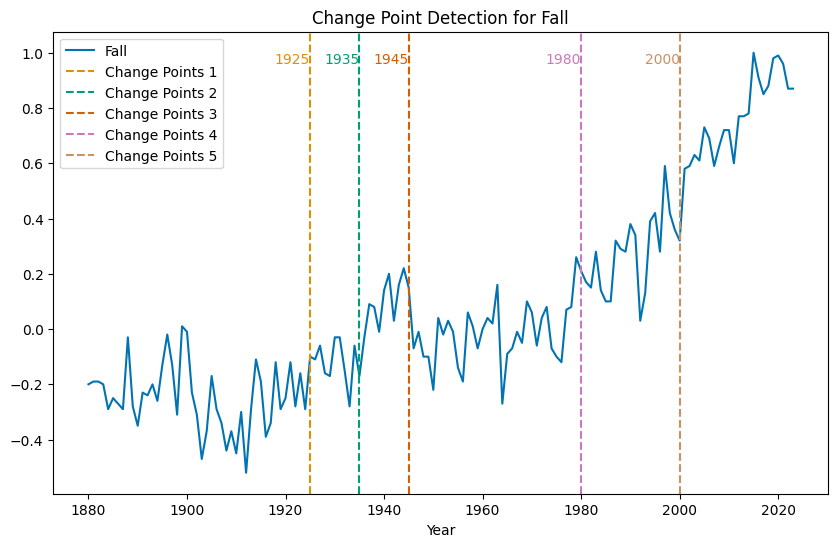

In [32]:
import ruptures as rpt

season_names = {'DJF': 'Winter', 'MAM': 'Spring', 'JJA': 'Summer', 'SON': 'Fall'}
for abb, season in season_names.items():
    points = df[abb].values
    print(points)

    # Search, binary segmentation
    algo = rpt.Binseg(model="rank").fit(points)
    result = algo.predict(n_bkps=5) # number of breakpoints to detect
    print(result)

    # Plotting
    plt.figure(figsize=(10,6))
    plt.plot(df['Year'], points, label=f'{season}')
    palette = sns.color_palette("colorblind")

    # Addinv vertical lines for change points
    for i, cp in enumerate(result[:-1]):
        year = df['Year'].iloc[cp]
        color = palette[i+1]
        plt.axvline(x=year, color=color, linestyle='--', label=f'Change Points {i+1}')
        y_pos = max(points)
        plt.text(year, y_pos, f'{year}', color=color, verticalalignment='top', horizontalalignment='right')
        print(f"Change Point {i+1}: Year {year}, Position {cp}, Y-Position {y_pos}")

    plt.xlabel('Year')
    plt.title(f'Change Point Detection for {season}')
    plt.legend()
    plt.show()

# Forecasting

## ARIMA (AutoRegressive Integrated Moving Average)

ARIMA is a popular forcasting method that combines autogressive features, moving averages, and differencing to create a model capable of capturing a wide range of time series data behaviors. 

Refrence:
https://www.justintodata.com/arima-models-in-python-time-series-prediction/

### Prepare Data for ARIMA

In [33]:
from statsmodels.tsa.arima.model import ARIMA

# Convert 'Year' to datetime format & set it as the Index to prepare the data
df['Year'] = pd.to_datetime(df['Year'], format='%Y')
df.set_index('Year', inplace=True)

ts = df['J-D']
ts

Year
1880-01-01   -0.17
1881-01-01   -0.09
1882-01-01   -0.11
1883-01-01   -0.18
1884-01-01   -0.29
              ... 
2019-01-01    0.98
2020-01-01    1.02
2021-01-01    0.85
2022-01-01    0.90
2023-01-01    0.90
Name: J-D, Length: 144, dtype: float64

### Check for Stationarity

ADF (Augmented Dickey-Fuller) Test 

In [34]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: 0.865343
p-value: 0.992621


* ACF Plot: This plot shows the correlation of the series with its lags. In the context of ARIMA modeling, it helps to identify the moving average component (q) parameter. 
* PACF Plot: This plot shows the partial correlation of a time series with its own lagged values, controlling for the values of the time series at all shorter lags. It can help in identifying the order of the autoregressive (p) component. 

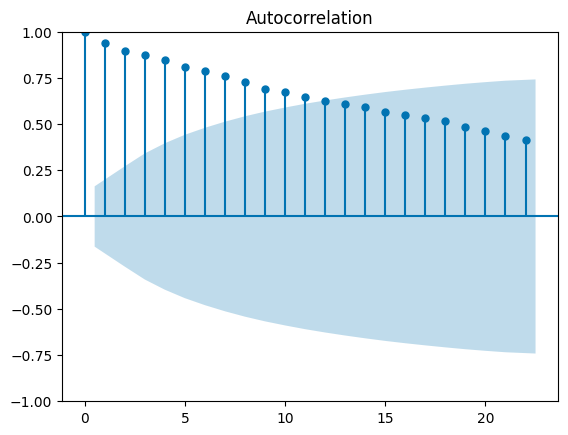

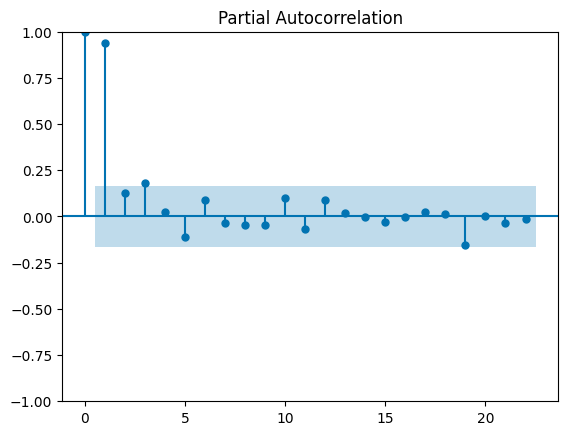

In [35]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(ts)
plot_pacf(ts)
plt.show()

ADF Statistic: -7.577575
p-value: 0.000000


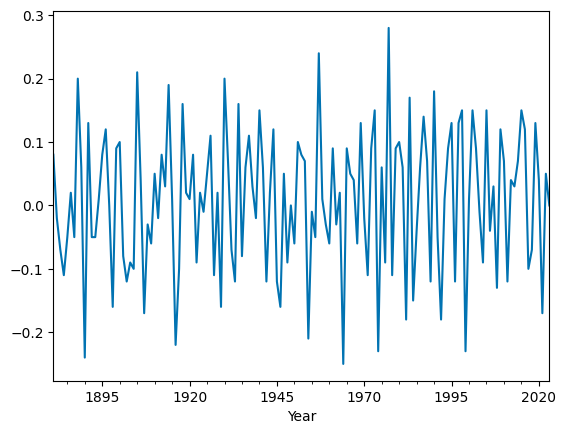

In [36]:
ts_diff = ts.diff().dropna()
ts_diff.plot()
result_diff = adfuller(ts_diff)
print('ADF Statistic: %f' % result_diff[0])
print('p-value: %f' % result_diff[1])

p-value is less than 0.05, meaning the data is now stationary. 

Set d parameter to 1.

### Determin parameters p, q

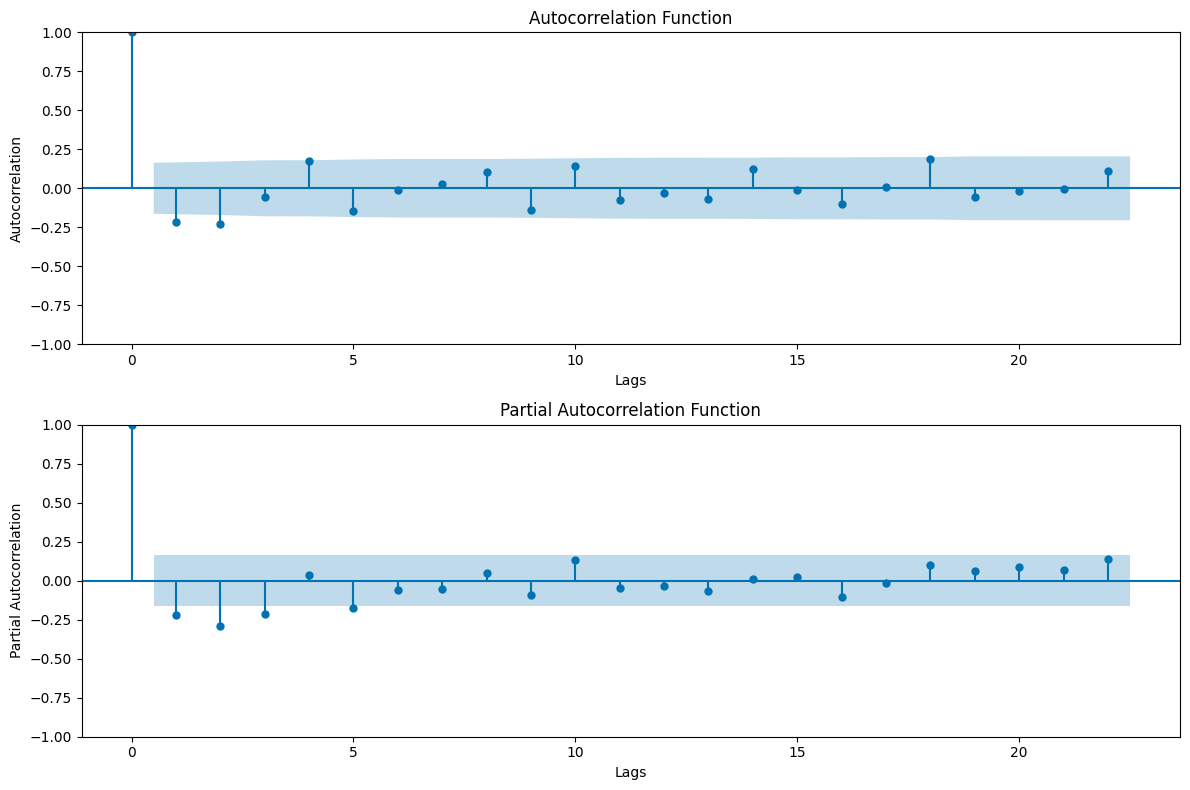

In [37]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2,1,figsize=(12,8))
# Autocorrelation funciton
plot_acf(ts_diff, ax=axes[0])
axes[0].set_title('Autocorrelation Function')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Autocorrelation')
# Partial autocorrelation function
plot_pacf(ts_diff, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function')
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()

A large spike at lag 0 in both the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots, followed by non-significant spikes for subsequent lags, suggests that the series may not need additional AR (p) or MA (q) terms beyond the differencing that has been applied.

### Fit the ARIMA Model

In [38]:
model = ARIMA(ts_diff, order=(0,1,0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    J-D   No. Observations:                  143
Model:                 ARIMA(0, 1, 0)   Log Likelihood                  47.450
Date:                Tue, 28 May 2024   AIC                            -92.899
Time:                        17:48:30   BIC                            -89.944
Sample:                    01-01-1881   HQIC                           -91.698
                         - 01-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0300      0.004      7.090      0.000       0.022       0.038
Ljung-Box (L1) (Q):                  35.22   Jarque-Bera (JB):                 2.29
Prob(Q):                              0.00   Pr

/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


## Forecasting

NOTE: Because this analysis notebook is for simple EDA and the size of dataset is very small, I won't split a data into train, test and validation to repare for the ML prediction. This section will cover a simple method of forcasting.

### Time-Series Predictions

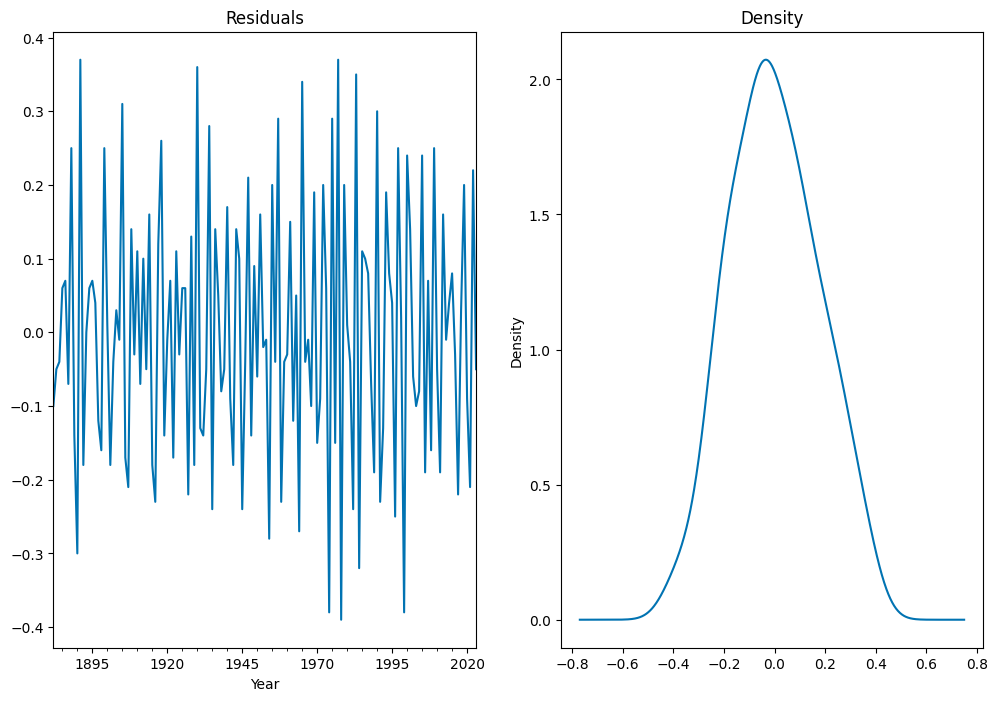

In [39]:
# Residual and Density Plots
resids = model_fit.resid[1:]

fig, ax = plt.subplots(1,2,figsize=(12,8))
resids.plot(title='Residuals', ax=ax[0])
resids.plot(title='Density', kind='kde', ax=ax[1])

plt.show()

In [40]:
forecast = model_fit.forecast(steps=50)
print(forecast)

2024-01-01   -6.938894e-18
2025-01-01   -6.938894e-18
2026-01-01   -6.938894e-18
2027-01-01   -6.938894e-18
2028-01-01   -6.938894e-18
2029-01-01   -6.938894e-18
2030-01-01   -6.938894e-18
2031-01-01   -6.938894e-18
2032-01-01   -6.938894e-18
2033-01-01   -6.938894e-18
2034-01-01   -6.938894e-18
2035-01-01   -6.938894e-18
2036-01-01   -6.938894e-18
2037-01-01   -6.938894e-18
2038-01-01   -6.938894e-18
2039-01-01   -6.938894e-18
2040-01-01   -6.938894e-18
2041-01-01   -6.938894e-18
2042-01-01   -6.938894e-18
2043-01-01   -6.938894e-18
2044-01-01   -6.938894e-18
2045-01-01   -6.938894e-18
2046-01-01   -6.938894e-18
2047-01-01   -6.938894e-18
2048-01-01   -6.938894e-18
2049-01-01   -6.938894e-18
2050-01-01   -6.938894e-18
2051-01-01   -6.938894e-18
2052-01-01   -6.938894e-18
2053-01-01   -6.938894e-18
2054-01-01   -6.938894e-18
2055-01-01   -6.938894e-18
2056-01-01   -6.938894e-18
2057-01-01   -6.938894e-18
2058-01-01   -6.938894e-18
2059-01-01   -6.938894e-18
2060-01-01   -6.938894e-18
2

**Manually fitting ARIMA by visual inspection doesn't seem to be working. Moving on to the Auto-Fitting ARIMA**

In [41]:
! pip install pmdarima 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.5 MB/s eta 0:00:00


### Auto-Fit ARIMA Model

Auto-Fit ARIMA model to obtain the p, d, and q parameters

In [42]:
from pmdarima import auto_arima

model = auto_arima(ts, start_p=1, start_q=1,
                   test='adf',       # Use adftest to find optimal 'd'
                   max_p=5, max_q=5, # Maximum p and q
                   m=1,              # Frequency of the series
                   d=None,           # Let the model determine 'd'
                   seasonal=False,   # No Seasonality
                   start_P=0, 
                   D=0, 
                   trace=True,
                   error_action='ignore',  
                   suppress_warnings=True, 
                   stepwise=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-239.395, Time=0.24 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-219.560, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-224.411, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-234.121, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-220.909, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-239.853, Time=0.25 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-235.027, Time=0.08 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-237.371, Time=0.18 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-237.853, Time=0.35 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-239.209, Time=0.24 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-239.647, Time=0.15 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-240.248, Time=0.42 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=-238.681, Time=1.14 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=-236.986, Time=1.61 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept

**Interpretation:**

Log Likelihood: The value doesn't tell its meaning until compared with other models, but the positive value suggest that the model is capturing some of the structures in the data.

AIC: The lower AIC is generally preferred. The AIC value indicates potentially good balance between model complexity and fit. 

BIC: The lower BIG is genrally preferred.

P>|z|: p-value associated with each parameter. Values less than 0.05 suggest that the parameter is statistically significant. `ar.L2` might not be contributing much to the model, because of its value is more than 0.05.

Ljung-Box Prob (Q): This checks for autocorrelation at all lags. A p-value grater than 0.05 suggests there is little evidence of autocorrelation, indicating a good fit.  

Jarque-Bera: This tests whether the residuals are normally distributed. A higher p-value suggests the residuals are normally distributed, which is a good sign. 

Heteroskedasticity: This checks whether the variance of the residuals is constant over time. The p-value grater than 0.05 suggests that there is no heteroskedasticity. 

Skew: Skewness measures the asymmetry of the prob distribution. 0 indicates a perfectly symmetrical distribution. Negative value means the distribution has a longer tail on the left side. 

Kurosis: This indicates the sharpness of the peak of a distribution curve. The standard value with the normal distribution is 3. A kurtosis of 2.26 suggests that the distribution of residuals is slightly flatter than a normal distribution of residuals, which could mean fewer extreme outliers in teh data. 

Given the SARIMAX Results, ARIMA(3,1,2) model has been reasonably well-fitted to the data. 

(3,1,2): The non-seasonal part of the model, where p=3, d=1, and q-2 is the best combination of parameters.

(0,0,0): This describes the seasonal component of the model. In this case, all zeros indicate that the model detected no seasonal effects in the data. 

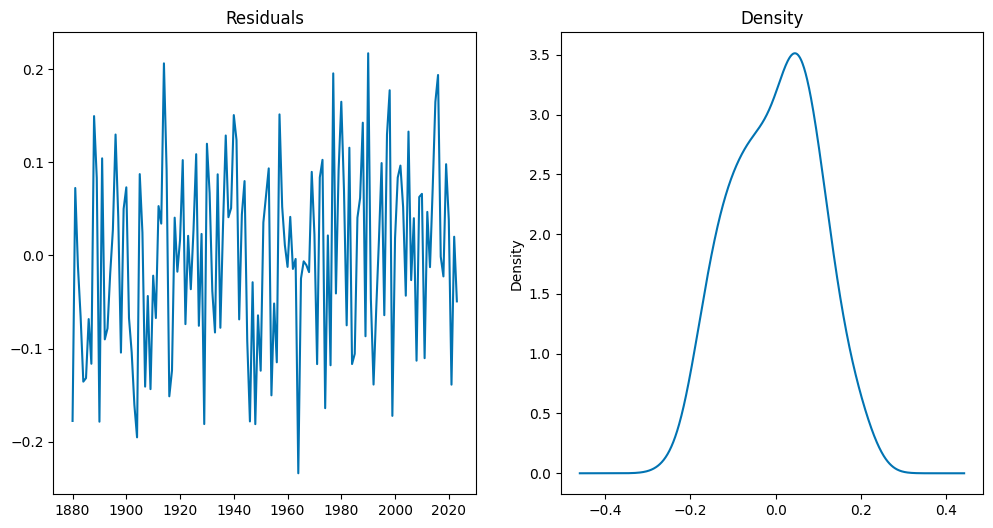

In [43]:
# Residual and Density Plots
# Extract residuals
resids_arima = pd.Series(model.resid())

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].plot(resids_arima)
ax[0].set_title('Residuals')

resids_arima.plot(kind='kde', ax=ax[1])
ax[1].set_title('Density')

plt.show()

### Plotting the ARIMA Forecast Model

DatetimeIndex(['2024-12-31', '2025-12-31', '2026-12-31', '2027-12-31',
               '2028-12-31', '2029-12-31', '2030-12-31', '2031-12-31',
               '2032-12-31', '2033-12-31', '2034-12-31', '2035-12-31',
               '2036-12-31', '2037-12-31', '2038-12-31', '2039-12-31',
               '2040-12-31', '2041-12-31', '2042-12-31', '2043-12-31',
               '2044-12-31', '2045-12-31', '2046-12-31', '2047-12-31',
               '2048-12-31', '2049-12-31', '2050-12-31', '2051-12-31',
               '2052-12-31', '2053-12-31', '2054-12-31', '2055-12-31',
               '2056-12-31', '2057-12-31', '2058-12-31', '2059-12-31',
               '2060-12-31', '2061-12-31', '2062-12-31', '2063-12-31',
               '2064-12-31', '2065-12-31', '2066-12-31', '2067-12-31',
               '2068-12-31', '2069-12-31', '2070-12-31', '2071-12-31',
               '2072-12-31', '2073-12-31', '2074-12-31', '2075-12-31',
               '2076-12-31', '2077-12-31', '2078-12-31', '2079-12-31',
      

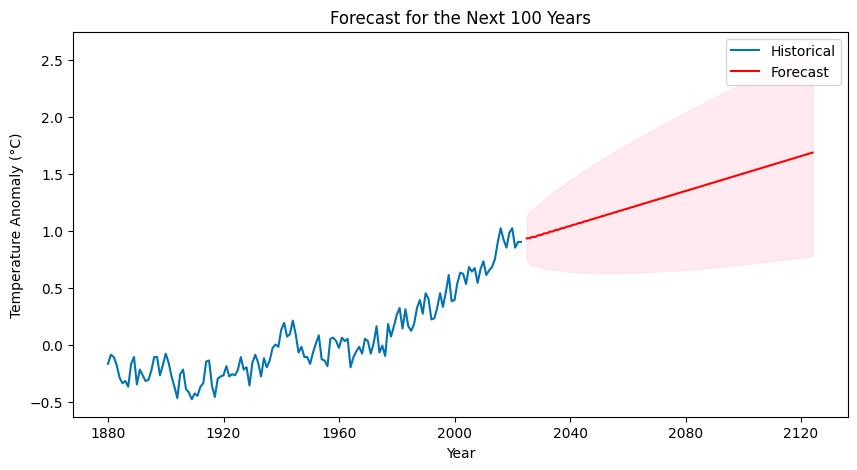

In [44]:
from pmdarima import auto_arima

# Forecasting for 100 years
n_periods = 100
forecast, conf_int = model.predict(n_periods=n_periods, return_conf_int=True)
# print(forecast)
# print(conf_int)

# Adjusting future_index for yearly data
# Ensure that 'ts' index is in DateTime format and the frequency is Yearly ('Y')
future_index = pd.date_range(start=ts.index[-1] + pd.offsets.DateOffset(years=1), 
                             periods=n_periods, 
                             freq='Y')
print(future_index)

# Plotting the forecast with the historical data
plt.figure(figsize=(10, 5))

plt.plot(ts.index, ts, label='Historical')
plt.plot(future_index, forecast, label='Forecast', color='red')
plt.fill_between(future_index, conf_int[:, 0], conf_int[:, 1], color='pink', alpha=0.3)

plt.title('Forecast for the Next 100 Years')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.legend()

plt.show()

### Adding the Benchmark Reference

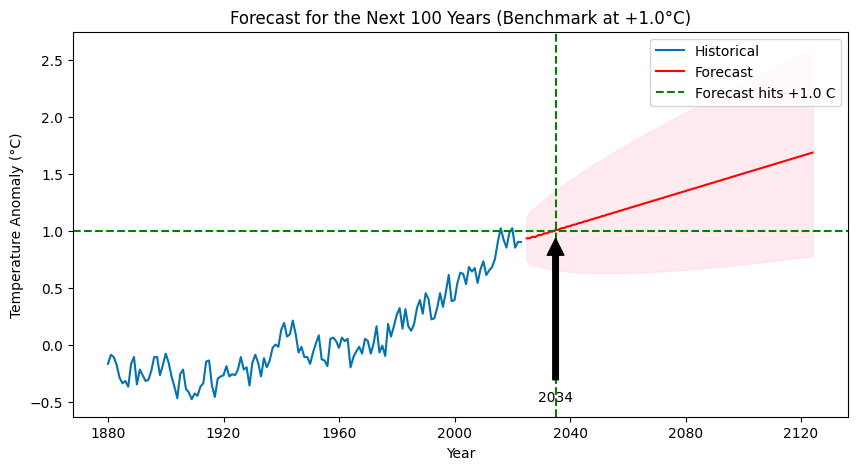

In [45]:
from pmdarima import auto_arima

# Forecasting for 100 years
n_periods = 100
forecast, conf_int = model.predict(n_periods=n_periods, return_conf_int=True)
# print(forecast)
# print(conf_int)

# Adjusting future_index for yearly data
# Ensure that 'ts' index is in DateTime format and the frequency is Yearly ('Y')
future_index = pd.date_range(start=ts.index[-1] + pd.offsets.DateOffset(years=1), 
                             periods=n_periods, 
                             freq='Y')
# print(future_index)

# Plotting the forecast with the historical data
plt.figure(figsize=(10, 5))

plt.plot(ts.index, ts, label='Historical')
plt.plot(future_index, forecast, label='Forecast', color='red')
plt.fill_between(future_index, conf_int[:, 0], conf_int[:, 1], color='pink', alpha=0.3)

# Add a horizontal line for the +1.5 anomaly
plt.axhline(y=1.0, color='green', linestyle='--')
# Return the first True index
hit_10_index = np.argmax(forecast>=1.0)
plt.axvline(x=future_index[hit_10_index], color='green', linestyle='--', label='Forecast hits +1.0 C')
plt.annotate("2034", 
             xy=(future_index[hit_10_index],1.0),
             xytext=(future_index[hit_10_index], -0.5),
            arrowprops=dict(facecolor='black', shrink=0.05),
            ha='center')

plt.title('Forecast for the Next 100 Years (Benchmark at +1.0°C)')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.legend()

## What Does This Mean??

### 1.5°C Benchmark

The Paris Agreement adopted in 2015 aims to limit global warming to below 1.5 degrees Celsius above pre-industrial levels of the global average temperature. The 1.5°C threshold is based on scientific evidence suggesting that keeping the global temperature below this level would significantly reduce the risks and impacts of climate change. 

### The Benchmark Consideration

The Agreement did not define a pre-industrial period for the anomaly calculation, though scientists generally consider the years from 1850 to 1900 to be a reliable reference. 

### Applying to This Dataset

The time range of this dataset starts from 1880 and it uses 1951-1980 period as a reference for temperature anomaly. Since the reference is not preindustrial period, it is essential to adjust the temperature anomaly benchmark to reflect the difference from pre-industrial levels. Since the 1951-1980 period is already warmer than the pre-industrial baseline, a direct 1.5°C increase would not represent the the Paris Agreement's goal in the visualization. 

### Adjusting the Benchmark

The visual inspection in the above visualization and the estimates suggest that the global average temperature of the mid-20th century had already increased by apploximately 0.3°C to 0.4°C compared to pre-industrial levels. 
Given the difference, I would adjust 0.5°C lower than the benchmark, which means +1.0°C for this analysis. 

## Projection

Visualizing NASA's climate data with an adjusted benchmark of a +1.0-degree Celsius temperature anomaly, relative to the 1951-1980 mean, and projecting that the threshold will be **reached by 2034** has significant impact on the global system. 

# This analysis suggests that the global temperatures are on a trajectory to **exceed a critical limit of climate change impacts within the next decade**. 


### Accelerated Climate Change Impacts

1. Increased Frequency of Extreme Weather Events
2. Ecosystem Disruptions
3. Sea-Level Rise
4. Socioeconomic Impacts

## What's Next For The Global Temperature Analysis

Here are some ideas how we could potentially expand this analysis.

1. Expand by incorporating additional forecasting models to compare the models
2. Run Multivariable Analysis by adding new dimensions like Greenhouse Gas Emsisions and Waste Productions